### Task: Using this sample dataset, create or optimize data preprocessing pipeline using opencv and pytorch and include image mask technique in the pipeline and save the output.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
data_path =  "/content/drive/MyDrive/AI_Vision_Extract_Nov25/COCO2017_SAMPLE"

In [ ]:

import cv2
import numpy as np
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import os
from pathlib import Path

# Create output directory
output_dir = "preprocessed_output"
os.makedirs(output_dir, exist_ok=True)
print(f" Output directory created: {output_dir}")

# Check device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f" Using device: {device}")


 Output directory created: preprocessed_output
 Using device: cuda


In [ ]:

image_dir = "/content/drive/MyDrive/AI_Vision_Extract_Nov25/COCO2017_SAMPLE/train2017"
mask_dir = "/content/drive/MyDrive/AI_Vision_Extract_Nov25/COCO2017_SAMPLE/mask_train2017"

# Get image files (.jpg)
image_files = sorted(list(Path(image_dir).glob("*.jpg")))

# Get mask files (.png)
mask_files = sorted(list(Path(mask_dir).glob("*.png")))

print(f" Found {len(image_files)} images (.jpg)")
print(f" Found {len(mask_files)} masks (.png)")

# Load one sample for demonstration
sample_image_path = str(image_files[0])
sample_mask_path = str(mask_files[0])

# Read with OpenCV
image = cv2.imread(sample_image_path)
mask = cv2.imread(sample_mask_path, cv2.IMREAD_GRAYSCALE)

print(f" Sample image: {Path(sample_image_path).name}")
print(f" Sample mask: {Path(sample_mask_path).name}")
print(f" Image shape: {image.shape}")
print(f" Mask shape: {mask.shape}")


 Found 11827 images (.jpg)
 Found 38104 masks (.png)
 Sample image: 000000000036.jpg
 Sample mask: 000000000009_mask.png
 Image shape: (640, 481, 3)
 Mask shape: (480, 640)


In [ ]:

def preprocess_image_opencv(image):
    # Convert BGR to RGB (OpenCV loads as BGR)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Resize to standard size
    image_resized = cv2.resize(image_rgb, (256, 256), interpolation=cv2.INTER_LINEAR)

    # Apply denoising
    image_denoised = cv2.fastNlMeansDenoisingColored(image_resized, None, 10, 10, 7, 21)

    # Enhance contrast using CLAHE
    lab = cv2.cvtColor(image_denoised, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_clahe = clahe.apply(l)
    lab_clahe = cv2.merge([l_clahe, a, b])
    image_enhanced = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)

    # Normalize to [0, 1]
    image_normalized = image_enhanced.astype(np.float32) / 255.0

    return image_normalized


def preprocess_mask_opencv(mask):
    # Resize to match image size
    mask_resized = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)

    # Apply binary threshold to ensure clean mask
    _, mask_binary = cv2.threshold(mask_resized, 127, 255, cv2.THRESH_BINARY)

    # Morphological operations to clean mask
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask_cleaned = cv2.morphologyEx(mask_binary, cv2.MORPH_CLOSE, kernel)
    mask_cleaned = cv2.morphologyEx(mask_cleaned, cv2.MORPH_OPEN, kernel)

    # Normalize to [0, 1]
    mask_normalized = mask_cleaned.astype(np.float32) / 255.0

    return mask_normalized


print(" OpenCV preprocessing functions ")


 OpenCV preprocessing functions 


In [ ]:

def apply_mask_technique(image, mask):
    # Ensure mask has 3 channels for multiplication
    if len(mask.shape) == 2:
        mask_3channel = np.stack([mask, mask, mask], axis=-1)
    else:
        mask_3channel = mask

    # Apply mask to image element-wise multiplication
    masked_image = image * mask_3channel

    # Extract bounding box of masked region
    mask_binary = (mask > 0.5).astype(np.uint8) * 255
    contours, _ = cv2.findContours(mask_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        x, y, w, h = cv2.boundingRect(contours[0])
        cropped_masked = masked_image[y:y+h, x:x+w]
    else:
        cropped_masked = masked_image

    return masked_image, cropped_masked


print(" Masking functions")


 Masking functions


In [ ]:

def to_pytorch_tensor(image):

    # Convert to tensor: H×W×C → C×H×W
    tensor = torch.from_numpy(image).permute(2, 0, 1).float()
    return tensor


def pytorch_augmentations(tensor):

    # Define augmentation pipeline
    augment = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Apply augmentations
    augmented = augment(tensor)

    return augmented


print(" PyTorch transformation functions")


 PyTorch transformation functions


In [ ]:
def preprocessing_pipeline(image_path, mask_path, save_output=True):

    print(f"\n{'='*60}")
    print(f"Processing: {Path(image_path).name}")
    print(f"{'='*60}")

    # Load image and mask
    image = cv2.imread(image_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    # STEP 1: OpenCV Preprocessing
    print("Step 1: Applying OpenCV preprocessing...")
    image_preprocessed = preprocess_image_opencv(image)
    mask_preprocessed = preprocess_mask_opencv(mask)

    # STEP 2: Apply Masking
    print("Step 2: Applying mask technique...")
    masked_image, cropped_masked = apply_mask_technique(image_preprocessed, mask_preprocessed)

    # STEP 3: Convert to PyTorch tensors
    print("Step 3: Converting to PyTorch tensors...")
    image_tensor = to_pytorch_tensor(image_preprocessed)
    mask_tensor = torch.from_numpy(mask_preprocessed).unsqueeze(0).float()
    masked_tensor = to_pytorch_tensor(masked_image)

    # STEP 4: Apply PyTorch augmentations
    print("Step 4: Applying PyTorch augmentations...")
    augmented_tensor = pytorch_augmentations(image_tensor)

    # STEP 5: Save outputs
    if save_output:
        print("Step 5: Saving outputs...")
        filename = Path(image_path).stem

        # Save as numpy arrays
        np.save(f"{output_dir}/{filename}_preprocessed.npy", image_preprocessed)
        np.save(f"{output_dir}/{filename}_mask.npy", mask_preprocessed)
        np.save(f"{output_dir}/{filename}_masked.npy", masked_image)

        # Save as PyTorch tensors
        torch.save(image_tensor, f"{output_dir}/{filename}_tensor.pt")
        torch.save(mask_tensor, f"{output_dir}/{filename}_mask_tensor.pt")

        # Save visual outputs as images
        cv2.imwrite(f"{output_dir}/{filename}_preprocessed.jpg",
                    (image_preprocessed * 255).astype(np.uint8))
        cv2.imwrite(f"{output_dir}/{filename}_mask.jpg",
                    (mask_preprocessed * 255).astype(np.uint8))
        cv2.imwrite(f"{output_dir}/{filename}_masked.jpg",
                    (masked_image * 255).astype(np.uint8))

        print(f" All outputs saved to {output_dir}/")

    return {
        'original': image,
        'preprocessed': image_preprocessed,
        'mask': mask_preprocessed,
        'masked': masked_image,
        'cropped': cropped_masked,
        'tensor': image_tensor,
        'mask_tensor': mask_tensor,
        'augmented_tensor': augmented_tensor
    }


print(" Complete pipeline function")


 Complete pipeline function


In [ ]:
# Process single sample
result = preprocessing_pipeline(sample_image_path, sample_mask_path, save_output=True)

print("\n Pipeline execution complete!")
print(f" Image tensor shape: {result['tensor'].shape}")
print(f" Mask tensor shape: {result['mask_tensor'].shape}")



Processing: 000000000036.jpg
Step 1: Applying OpenCV preprocessing...
Step 2: Applying mask technique...
Step 3: Converting to PyTorch tensors...
Step 4: Applying PyTorch augmentations...
Step 5: Saving outputs...
 All outputs saved to preprocessed_output/

 Pipeline execution complete!
 Image tensor shape: torch.Size([3, 256, 256])
 Mask tensor shape: torch.Size([1, 256, 256])


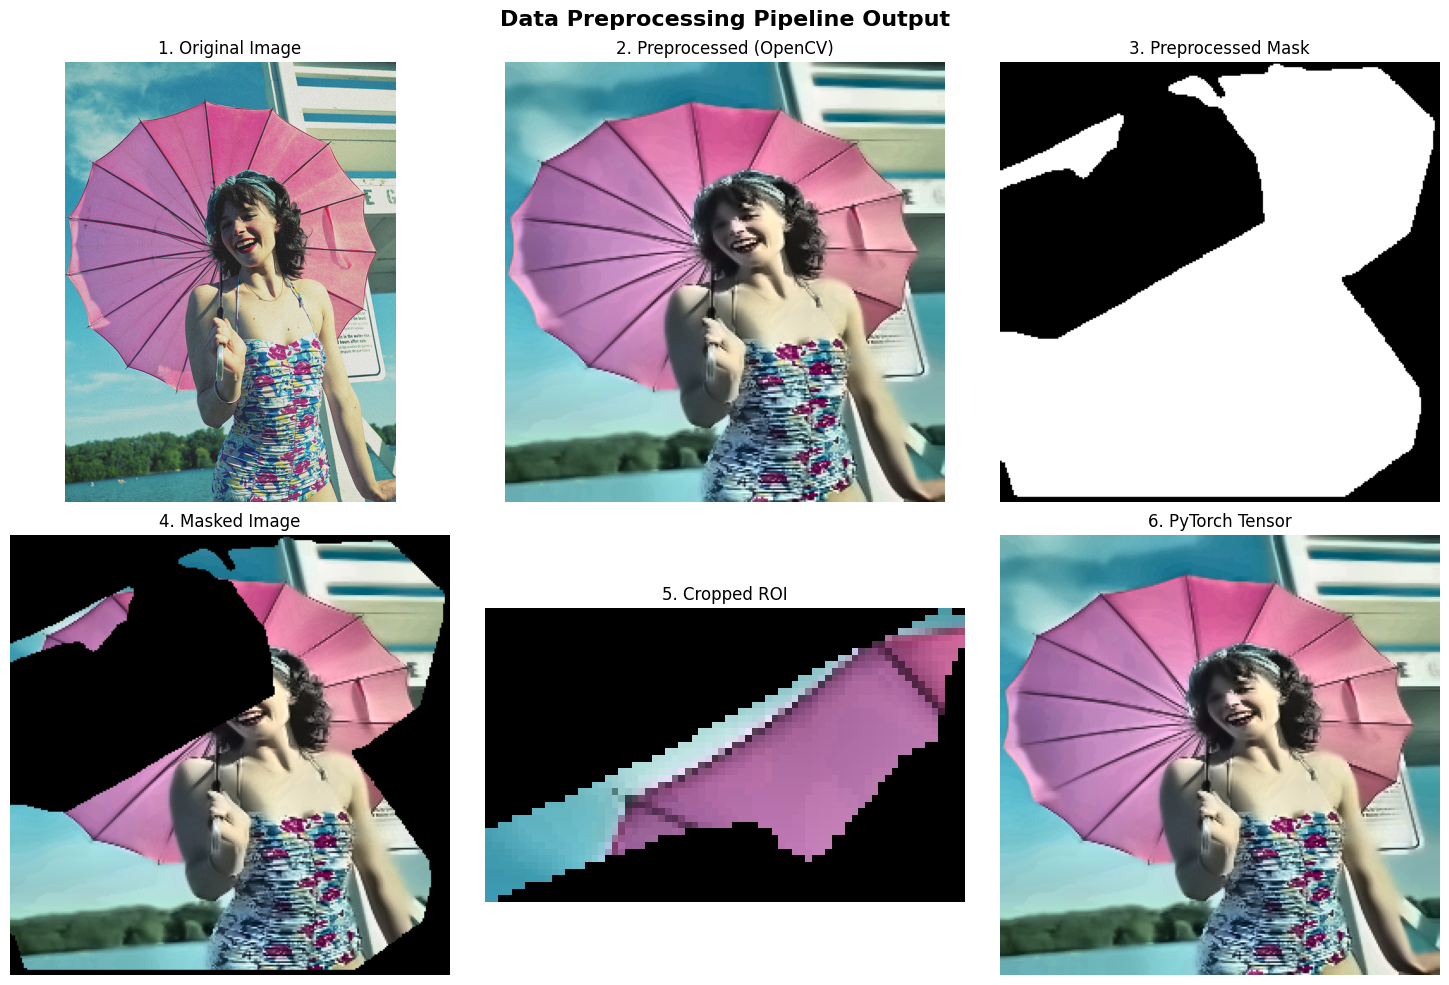

 Visualization saved


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Data Preprocessing Pipeline Output', fontsize=16, fontweight='bold')

# Row 1
axes[0, 0].imshow(cv2.cvtColor(result['original'], cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('1. Original Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(result['preprocessed'])
axes[0, 1].set_title('2. Preprocessed (OpenCV)')
axes[0, 1].axis('off')

axes[0, 2].imshow(result['mask'], cmap='gray')
axes[0, 2].set_title('3. Preprocessed Mask')
axes[0, 2].axis('off')

# Row 2
axes[1, 0].imshow(result['masked'])
axes[1, 0].set_title('4. Masked Image')
axes[1, 0].axis('off')

axes[1, 1].imshow(result['cropped'])
axes[1, 1].set_title('5. Cropped ROI')
axes[1, 1].axis('off')

# PyTorch tensor visualization
tensor_vis = result['tensor'].permute(1, 2, 0).numpy()
axes[1, 2].imshow(tensor_vis)
axes[1, 2].set_title('6. PyTorch Tensor')
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig(f"{output_dir}/pipeline_visualization.png", dpi=150, bbox_inches='tight')
plt.show()

print(" Visualization saved")


In [ ]:
def batch_preprocess(image_dir, mask_dir, output_dir, max_samples=None):
    # here Images are .jpg, masks are .png
    image_files = sorted(list(Path(image_dir).glob("*.jpg")))
    mask_files = sorted(list(Path(mask_dir).glob("*.png")))

    if max_samples:
        image_files = image_files[:max_samples]
        mask_files = mask_files[:max_samples]

    print(f"\n{'='*60}")
    print(f"BATCH PROCESSING {len(image_files)} IMAGES")
    print(f"{'='*60}\n")

    for img_path, mask_path in zip(image_files, mask_files):
        try:
            preprocessing_pipeline(str(img_path), str(mask_path), save_output=True)
        except Exception as e:
            print(f" Error processing {img_path.name}: {e}")

    print(f"\n Batch processing complete!")
    print(f"  Outputs saved to: {output_dir}")

